# Denoise the EDX HSI with channel-wise BM3D

In [39]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
from bm3d import bm3d, BM3DStages
from bm4d import bm4d, BM4DStages
import pickle
import copy
import time
import humanfriendly
from skimage.restoration import estimate_sigma
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load aligned dataset

In [3]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)
tile.summary()

,operation,parameters,haadf size,EDX size,notes
0,crop,"crop_idx=(slice(None, None, None), slice(None,...","(2048, 2048)","(2048, 2048, 4000)",None
1,binning,"dim=(2048, 2048, 250)","(2048, 2048)","(2048, 2048, 250)",None
2,sofima_align,"hsi_stack_loc_path=tmp/unaligned_hsi, alignmen...","(2048, 2048)","(2048, 2048, 250)",None


### Denoise

In [ ]:
#bm3d_hsi(self, estimation_band=None, sigma=None, pad_remove=0)
tile_bm3d = tile.apply("bm3d_hsi", parameters={"estimation_band": None, "pad_remove": 50},copy_instance=True)

### Save the denoised tile to memory

In [18]:
# save to memory
import pickle
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"../preprocessing_basic/results/preprocessed_edx/{timestamp}_tile_aligned_denoised(bm3d).pkl", "wb") as f:
    pickle.dump(tile_bm3d, f)


### Load 100 frame tile as reference 

In [19]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100, sum_frames=True, haadf_last_frame=False)
print(haadf.shape)

tile_ref = EM_EDX(haadf[0,:,:], edx, xray_energies)
tile_ref.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_ref.apply("binning", parameters={"dim": (2048, 2048, 250)})
#tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)


<EM_EDX | 2 steps logged>

## BM3D- PCA

In [40]:
tile_bm3dpca = tile.apply("PCA_bm3d", parameters={"k": 5},copy_instance=True)

 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!


/Users/aj/Desktop/work/PostDoc_UMCG/work/analysis/EDX_Project/PreHyperspectralEDX/utils.py:85: RuntimeWarning: invalid value encountered in divide
  return (data - np.min(data)) / (np.max(data) - np.min(data)), min, max
<string>:41: RuntimeWarning: divide by zero encountered in scalar divide


 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in

### Compare Silhouette scores

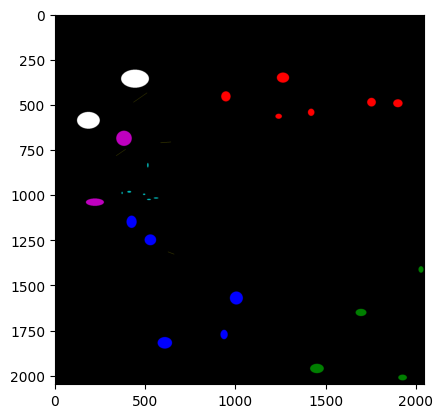

In [22]:
# Get masks
# get the hand-annotated masks and display them
mask_dir = os.path.join(os.path.dirname(os.getcwd()),'data', 'masks_full_res')
masks = create_masks(mask_dir)
colors = ['k','r','g','b','c','m','y','w']
newcmap = ListedColormap(colors)
plt.imshow(masks,cmap=newcmap)
plt.show()

### Get rid of nan values

In [24]:
tile.EDX = np.nan_to_num(tile.EDX, nan=0.0)
tile_bm3d.EDX = np.nan_to_num(tile_bm3d.EDX, nan=0.0)

In [41]:
# compute sil scores for both
sil_img = sil_scores(tile.EDX, masks, metric='cosine')
sil_img_ref = sil_scores(tile_ref.EDX, masks, metric='cosine')
sil_img1 = sil_scores(tile_bm3d.EDX, masks, metric='cosine')
sil_img2 = sil_scores(tile_bm3dpca.EDX, masks, metric='cosine')


# compute global vmin/vmax 
vmin = np.nanmin(np.array([sil_img,sil_img_ref,sil_img1,sil_img2]))
vmax = np.nanmax(np.array([sil_img,sil_img_ref,sil_img1,sil_img2]))

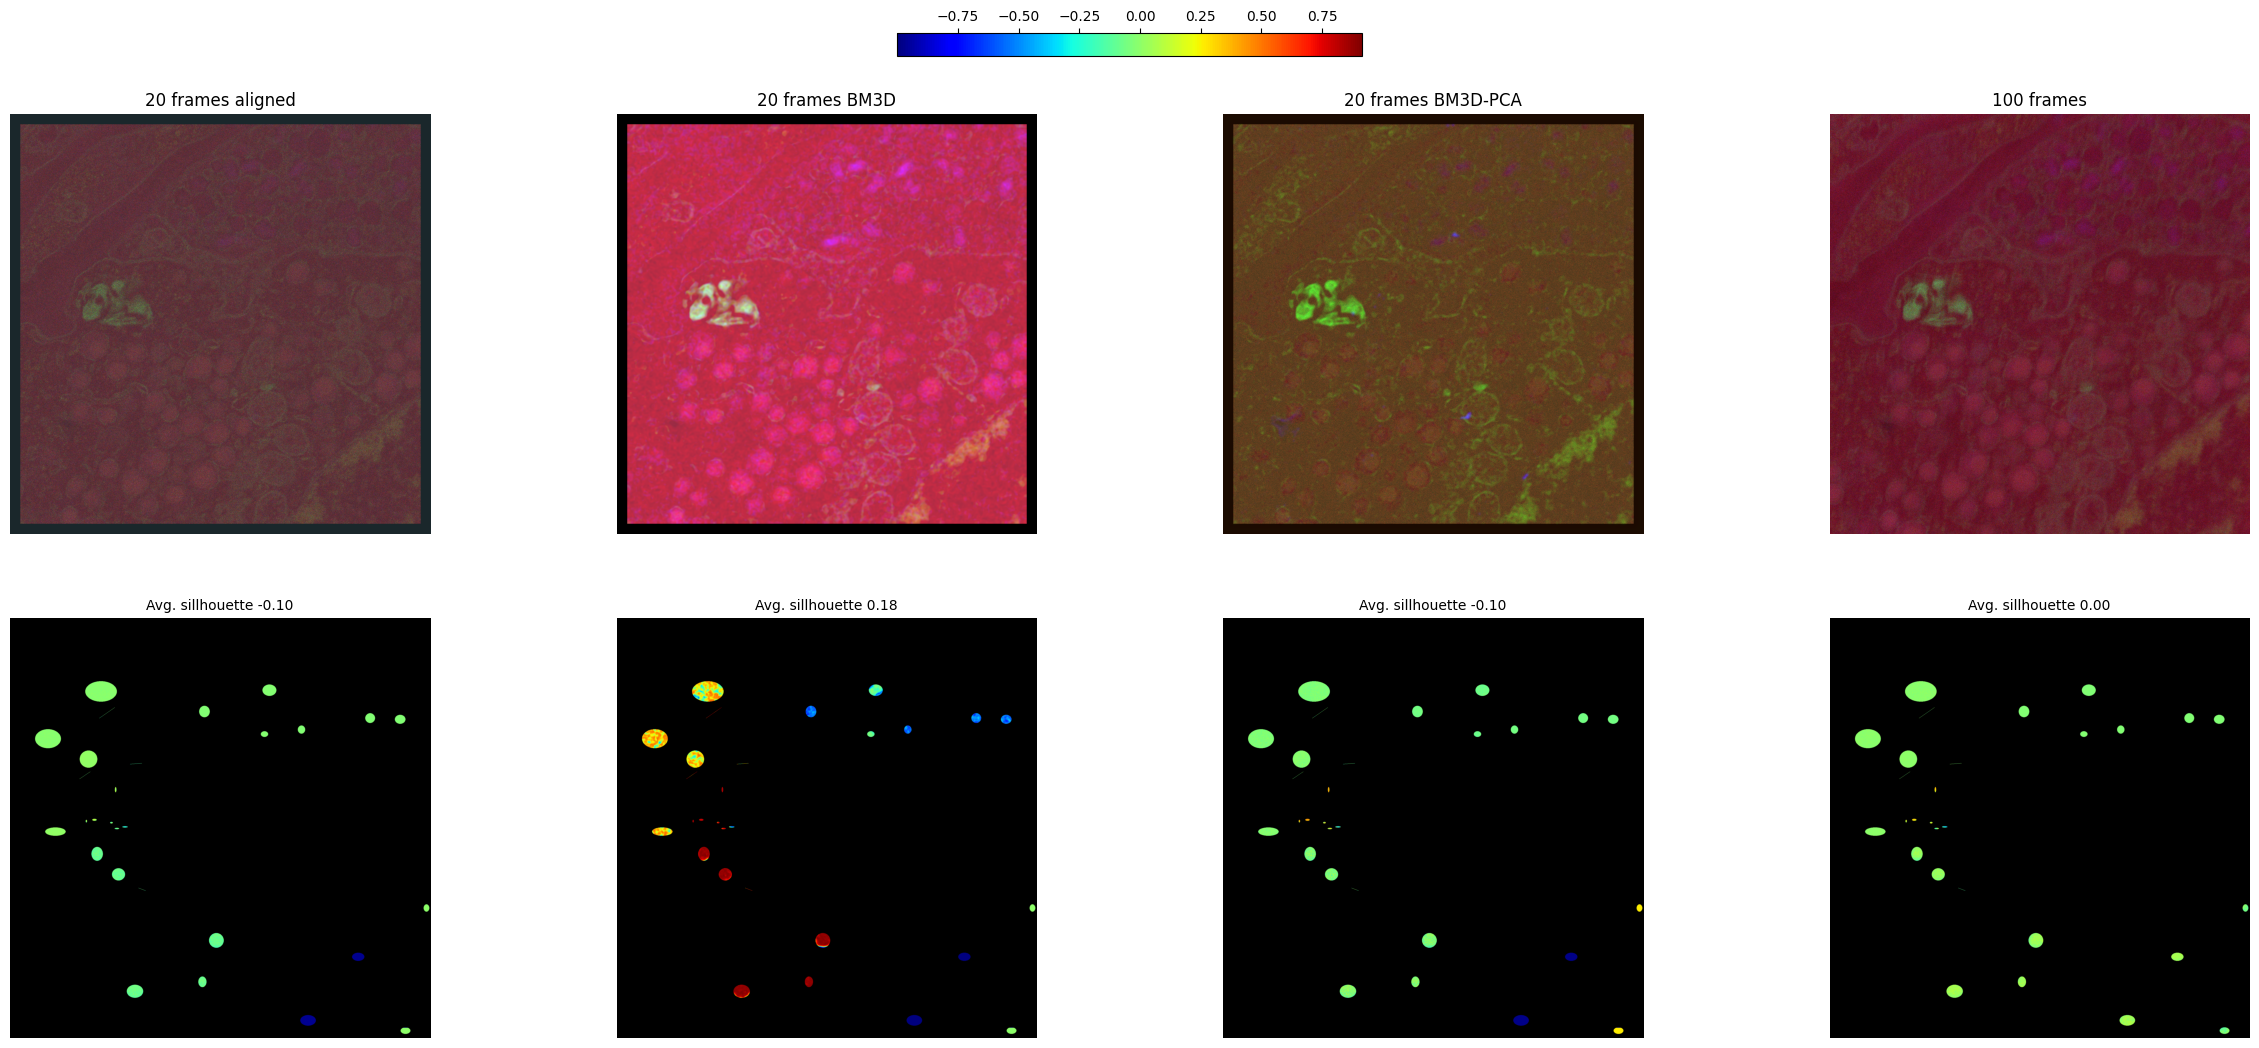

In [43]:
# modify jet so NaNs appear black
cmap = plt.cm.jet.copy()
cmap.set_bad(color='black')

bands=[4,25,28]
f, ax = plt.subplots(2,4,figsize=(30, 15))
ax[0][0].imshow(tile.FalseColor(bands))
ax[0][0].set_title('20 frames aligned')
ax[0][1].imshow(tile_bm3d.FalseColor(bands))
ax[0][1].set_title('20 frames BM3D')
ax[0][2].imshow(tile_bm3dpca.FalseColor(bands))
ax[0][2].set_title('20 frames BM3D-PCA')
ax[0][3].imshow(tile_ref.FalseColor(bands))
ax[0][3].set_title('100 frames')

im = ax[1][0].imshow(sil_img,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][0].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img),fontsize=10)


im = ax[1][1].imshow(sil_img1,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img1),fontsize=10)

im = ax[1][2].imshow(sil_img2,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][2].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img2),fontsize=10)

im = ax[1][3].imshow(sil_img_ref,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][3].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img_ref),fontsize=10)

for i in range(2):
    for j in range(4):
        ax[i][j].axis('off')

# one shared colorbar
plt.colorbar(im, ax=ax.ravel().tolist(), shrink=0.2,location='top')

#plt.tight_layout()
plt.show()

In [ ]:
tile_ref = tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})
tile = tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})
tile_bm3d = tile_bm3d.apply("MeanFilterEDX", parameters={"kernel_size": 3})

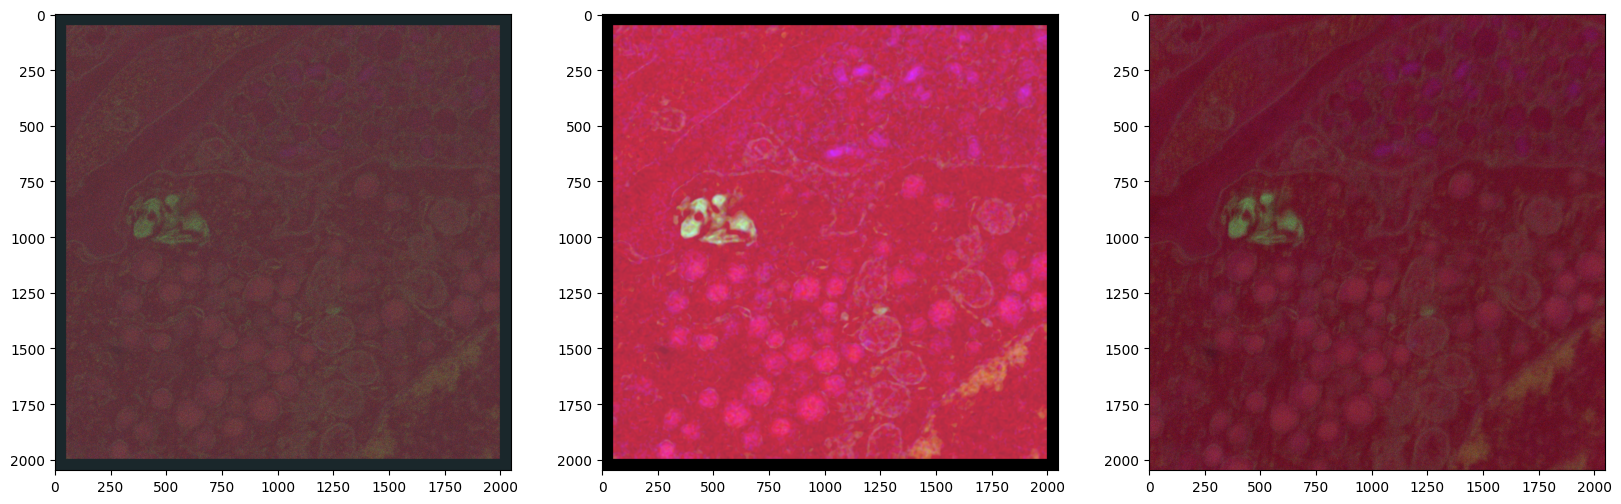

In [35]:
bands = [4,25,28]
f, ax = plt.subplots(1,3,figsize=(20,10))
ax[0].imshow(tile.FalseColor(bands))
ax[1].imshow(tile_bm3d.FalseColor(bands))
ax[2].imshow(tile_ref.FalseColor(bands))